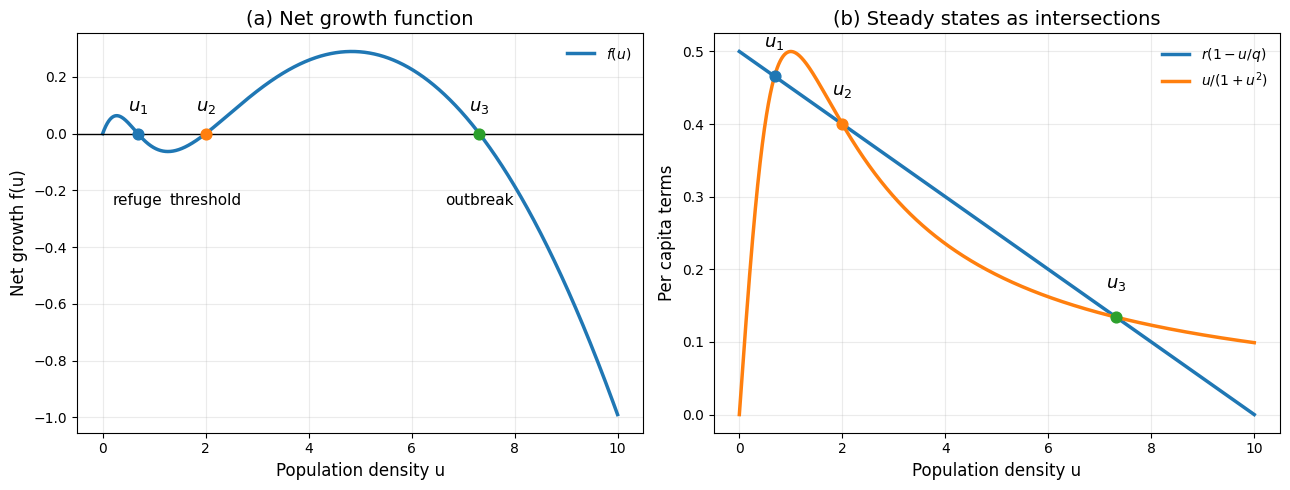

In [ ]:
#libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq #used for finding roots

#functions
def f(u):
    return r*u*(1 - u/q) - u**2/(1 + u**2)

def growth_per_capita(u):
    return r*(1 - u/q)

def predation_per_capita(u):
    return u/(1 + u**2)

def root_equation(u):
    return growth_per_capita(u) - predation_per_capita(u)

#parameters
r = 0.5
q = 10

#domain
u = np.linspace(0, 10, 3000)

#steady states with a for statement for plots
roots = []
for i in range(len(u) - 1):
    if root_equation(u[i]) * root_equation(u[i + 1]) < 0:
        root = brentq(root_equation, u[i], u[i + 1])
        roots.append(root)

#figure setup
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

#Figure A: Net growth f(u)
axes[0].plot(u, f(u), linewidth=2.5, label=r"$f(u)$")
axes[0].axhline(0, linewidth=1, color="black")

for root, label in zip(roots, [r"$u_1$", r"$u_2$", r"$u_3$"]):
    axes[0].scatter(root, 0, s=60, zorder=3)
    axes[0].text(root, 0.08, label, ha="center", fontsize=13)

axes[0].text(roots[0], -0.25, "refuge", ha="center", fontsize=11)
axes[0].text(roots[1], -0.25, "threshold", ha="center", fontsize=11)
axes[0].text(roots[2], -0.25, "outbreak", ha="center", fontsize=11)

axes[0].set_title("(a) Net growth function", fontsize=14)
axes[0].set_xlabel("Population density u", fontsize=12)
axes[0].set_ylabel("Net growth f(u)", fontsize=12)
axes[0].grid(alpha=0.25)
axes[0].legend(frameon=False)

#Figure B: Steady state intersections
axes[1].plot(u, growth_per_capita(u), linewidth=2.5, label=r"$r(1-u/q)$")
axes[1].plot(u, predation_per_capita(u), linewidth=2.5, label=r"$u/(1+u^2)$")

for root, label in zip(roots, [r"$u_1$", r"$u_2$", r"$u_3$"]):
    y = predation_per_capita(root)
    axes[1].scatter(root, y, s=60, zorder=3)
    axes[1].text(root, y + 0.04, label, ha="center", fontsize=13)

axes[1].set_title("(b) Steady states as intersections", fontsize=14)
axes[1].set_xlabel("Population density u", fontsize=12)
axes[1].set_ylabel("Per capita terms", fontsize=12)
axes[1].grid(alpha=0.25)
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()